In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import yfinance as yf
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import euclidean

In [36]:
diabetes_data = pd.read_excel('Diabetes_Data.xlsx')

print(f"Shape: {diabetes_data.shape}")
print(f"\nColumns: {diabetes_data.columns.tolist()}")
print(f"\nFirst 5 rows:\n{diabetes_data.head()}")


Shape: (442, 11)

Columns: ['AGE', 'SEX', 'BMI', 'BP', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'Y']

First 5 rows:
   AGE  SEX   BMI     BP   S1     S2    S3   S4      S5  S6    Y
0   59    2  32.1  101.0  157   93.2  38.0  4.0  4.8598  87  151
1   48    1  21.6   87.0  183  103.2  70.0  3.0  3.8918  69   75
2   72    2  30.5   93.0  156   93.6  41.0  4.0  4.6728  85  141
3   24    1  25.3   84.0  198  131.4  40.0  5.0  4.8903  89  206
4   50    1  23.0  101.0  192  125.4  52.0  4.0  4.2905  80  135


QUESTION 1.1: CORRELATION ANALYSIS


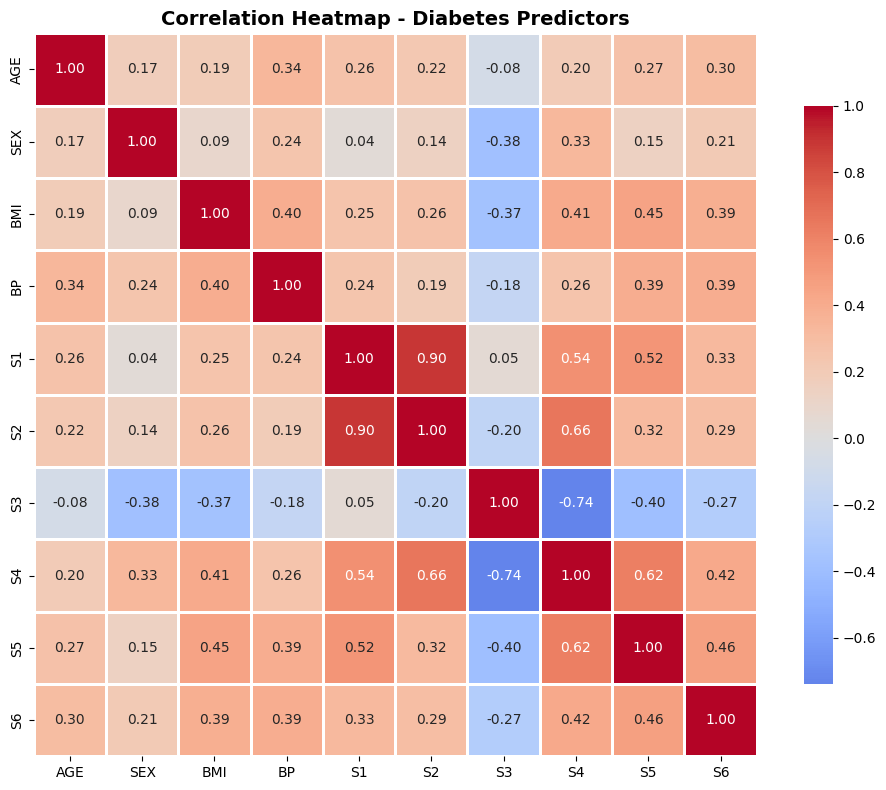


Correlation Matrix:
          AGE       SEX       BMI        BP        S1        S2        S3  \
AGE  1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
SEX  0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
BMI  0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
BP   0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
S1   0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
S2   0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
S3  -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
S4   0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
S5   0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
S6   0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   

           S4        S5        S6  
AGE  0.203841  0.270774  0.301731  
SEX  0.332115  0.149916  0.208133  
BMI  0.413807  0.446157

In [37]:
print("QUESTION 1.1: CORRELATION ANALYSIS")

predictors = diabetes_data.drop('Y', axis=1)
corr_mat = predictors.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Diabetes Predictors', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nCorrelation Matrix:\n{corr_mat}")

In [38]:
print("1.3: FULL MULTIVARIATE LINEAR MODEL")

X = diabetes_data.drop('Y', axis=1)
y = diabetes_data['Y']
X_const = sm.add_constant(X)

ols_model = sm.OLS(y, X_const).fit()

y_fitted = ols_model.predict(X_const)
mse_full = mean_squared_error(y, y_fitted)
r2_full = r2_score(y, y_fitted)
n_obs = len(y)
n_pred = X.shape[1]
adj_r2_full = 1 - (1 - r2_full) * (n_obs - 1) / (n_obs - n_pred - 1)

print(f"\nMODEL PERFORMANCE:")
print(f"   • Mean Squared Error: {mse_full:.2f}")
print(f"   • R²: {r2_full:.4f}")
print(f"   • Adjusted R²: {adj_r2_full:.4f}")

print("FULL MODEL SUMMARY")
print(ols_model.summary())

print("VARIABLE SIGNIFICANCE (α = 0.05)")

sig_list = []
insig_list = []

for variable in X.columns:
    p_val = ols_model.pvalues[variable]
    beta = ols_model.params[variable]
    
    if p_val < 0.05:
        sig_list.append(variable)
        print(f" {variable:6s}: p={p_val:.4f}, β={beta:7.2f} [SIGNIFICANT]")
    else:
        insig_list.append(variable)
        print(f" {variable:6s}: p={p_val:.4f}, β={beta:7.2f} [NOT SIGNIFICANT]")

print(f"\nSummary: {len(sig_list)}/{len(X.columns)} variables significant")
print(f"Insignificant variables: {insig_list if insig_list else 'None'}")

1.3: FULL MULTIVARIATE LINEAR MODEL

MODEL PERFORMANCE:
   • Mean Squared Error: 2859.70
   • R²: 0.5177
   • Adjusted R²: 0.5066
FULL MODEL SUMMARY
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sat, 10 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        19:16:39   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [

In [39]:
def stepwise_forward(X_data, y_data, alpha=0.05, verbose=True):
    available = list(X_data.columns)
    selected = []
    
    if verbose:
        print("\nFORWARD STEPWISE PROCEDURE")
        print("="*70)
    
    iteration = 0
    while True:
        iteration += 1
        remaining = list(set(available) - set(selected))
        
        if not remaining:
            break
        
        best_p = 1.0
        best_var = None
        
        if verbose:
            print(f"\nIteration {iteration}:")
            print(f"  Current model: {selected if selected else 'intercept only'}")
            print(f"  Candidates tested: {len(remaining)}")
        
        for candidate in remaining:
            test_vars = selected + [candidate]
            X_temp = sm.add_constant(X_data[test_vars])
            temp_model = sm.OLS(y_data, X_temp).fit()
            p_value = temp_model.pvalues[candidate]
            
            if verbose:
                status = "✓" if p_value < alpha else " "
                print(f"    [{status}] {candidate}: p = {p_value:.4f}")
            
            if p_value < best_p:
                best_p = p_value
                best_var = candidate
        
        if best_p < alpha:
            selected.append(best_var)
            if verbose:
                print(f"  → INCLUDE {best_var} (p = {best_p:.4f})")
        else:
            if verbose:
                print(f"  → STOP: Best p-value = {best_p:.4f} (threshold = {alpha})")
            break
    
    if selected:
        X_final = sm.add_constant(X_data[selected])
        final_model = sm.OLS(y_data, X_final).fit()
    else:
        X_final = sm.add_constant(pd.DataFrame(np.ones(len(y_data))))
        final_model = sm.OLS(y_data, X_final).fit()
    
    return selected, final_model


In [40]:
print("1.5: STEPWISE FORWARD SELECTION APPLICATION")
selected_features, stepwise_fit = stepwise_forward(X, y, alpha=0.05)
print("STEPWISE SELECTION RESULTS")
print(f"\nSelected features: {selected_features}")
print(f"Number selected: {len(selected_features)}")

1.5: STEPWISE FORWARD SELECTION APPLICATION

FORWARD STEPWISE PROCEDURE

Iteration 1:
  Current model: intercept only
  Candidates tested: 10
    [✓] S2: p = 0.0002
    [✓] S5: p = 0.0000
    [✓] S3: p = 0.0000
    [✓] BP: p = 0.0000
    [✓] S1: p = 0.0000
    [ ] SEX: p = 0.3664
    [✓] S6: p = 0.0000
    [✓] BMI: p = 0.0000
    [✓] S4: p = 0.0000
    [✓] AGE: p = 0.0001
  → INCLUDE BMI (p = 0.0000)

Iteration 2:
  Current model: ['BMI']
  Candidates tested: 9
    [ ] S2: p = 0.5758
    [✓] S5: p = 0.0000
    [✓] S3: p = 0.0000
    [✓] BP: p = 0.0000
    [ ] S1: p = 0.0796
    [ ] SEX: p = 0.8226
    [✓] S6: p = 0.0000
    [✓] S4: p = 0.0000
    [✓] AGE: p = 0.0364
  → INCLUDE S5 (p = 0.0000)

Iteration 3:
  Current model: ['BMI', 'S5']
  Candidates tested: 8
    [ ] S2: p = 0.0904
    [✓] S3: p = 0.0038
    [✓] BP: p = 0.0000
    [ ] SEX: p = 0.1444
    [ ] S6: p = 0.1468
    [✓] S1: p = 0.0033
    [ ] S4: p = 0.3915
    [ ] AGE: p = 0.8158
  → INCLUDE BP (p = 0.0000)

Iteration 4:
 

In [41]:
if selected_features:
    X_step = sm.add_constant(X[selected_features])
    y_step_fitted = stepwise_fit.predict(X_step)
    mse_step = mean_squared_error(y, y_step_fitted)
    r2_step = r2_score(y, y_step_fitted)
    n_step = len(selected_features)
    adj_r2_step = 1 - (1 - r2_step) * (n_obs - 1) / (n_obs - n_step - 1)
    
    print(f"\nSTEPWISE MODEL METRICS:")
    print(f"   • MSE: {mse_step:.2f}")
    print(f"   • R²: {r2_step:.4f}")
    print(f"   • Adjusted R²: {adj_r2_step:.4f}")
    
    print("STEPWISE MODEL DETAILS")
    print(stepwise_fit.summary())
    
    print("MODEL COMPARISON")

    
    print(f"\n{'Metric':<25} {'Full Model':>15} {'Stepwise':>15} {'Change':>15}")
    print(f"{'Predictors':<25} {n_pred:>15} {n_step:>15} {n_step-n_pred:>15}")
    print(f"{'MSE':<25} {mse_full:>15.2f} {mse_step:>15.2f} {mse_step-mse_full:>15.2f}")
    print(f"{'R²':<25} {r2_full:>15.4f} {r2_step:>15.4f} {r2_step-r2_full:>15.4f}")
    print(f"{'Adj R²':<25} {adj_r2_full:>15.4f} {adj_r2_step:>15.4f} {adj_r2_step-adj_r2_full:>15.4f}")
    
    reduction = ((n_pred - n_step) / n_pred) * 100
    print(f"\n   • Dimensionality reduction: {reduction:.1f}%")
    print(f"   • Variables removed: {n_pred - n_step}")
    
    if adj_r2_step >= adj_r2_full:
        print(f"   • Result: Improved parsimony without sacrificing fit ")
    else:
        print(f"   • Result: Trade-off between complexity and fit")


STEPWISE MODEL METRICS:
   • MSE: 2876.68
   • R²: 0.5149
   • Adjusted R²: 0.5082
STEPWISE MODEL DETAILS
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     76.95
Date:                Sat, 10 Jan 2026   Prob (F-statistic):           3.01e-65
Time:                        19:16:39   Log-Likelihood:                -2387.3
No. Observations:                 442   AIC:                             4789.
Df Residuals:                     435   BIC:                             4817.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [42]:
titanic_df = pd.read_csv('titanic3.csv')

print(f"Dataset Shape: {titanic_df.shape}")
print(f"\nColumns: {titanic_df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{titanic_df.head()}")
print(f"\nData Info:\n{titanic_df.info()}")
print(f"\nMissing Values:\n{titanic_df.isnull().sum()}")

Dataset Shape: (1309, 14)

Columns: ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']

First 5 rows:
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

     age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.00      0      0   24160  211.3375       B5        S    2    NaN   
1   0.92      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.00      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.00      1      2  113781  151.5500 

In [43]:
print("2.2: OVERALL SURVIVAL PROBABILITY")

total_passengers = len(titanic_df)
total_survived = titanic_df['survived'].sum()
survival_prob = total_survived / total_passengers

print(f"\nTotal Passengers: {total_passengers}")
print(f"Total Survived: {total_survived}")
print(f"Total Died: {total_passengers - total_survived}")
print(f"\nOverall Survival Probability: {survival_prob:.4f} ({survival_prob*100:.2f}%)")
print(f"Overall Death Probability: {1-survival_prob:.4f} ({(1-survival_prob)*100:.2f}%)")


2.2: OVERALL SURVIVAL PROBABILITY

Total Passengers: 1309
Total Survived: 500
Total Died: 809

Overall Survival Probability: 0.3820 (38.20%)
Overall Death Probability: 0.6180 (61.80%)


In [44]:
print("2.3: SURVIVAL PROBABILITIES BY CLASS, SEX, AGE")

print("\nSURVIVAL BY PASSENGER CLASS:")
class_survival = titanic_df.groupby('pclass')['survived'].agg(['sum', 'count', 'mean'])
class_survival.columns = ['Survived', 'Total', 'Survival_Rate']
class_survival['Died'] = class_survival['Total'] - class_survival['Survived']
print(class_survival)

print("\n\nSURVIVAL BY SEX:")
sex_survival = titanic_df.groupby('sex')['survived'].agg(['sum', 'count', 'mean'])
sex_survival.columns = ['Survived', 'Total', 'Survival_Rate']
sex_survival['Died'] = sex_survival['Total'] - sex_survival['Survived']
print(sex_survival)

print("\n\nSURVIVAL BY CLASS AND SEX:")
class_sex_survival = titanic_df.groupby(['pclass', 'sex'])['survived'].agg(['sum', 'count', 'mean'])
class_sex_survival.columns = ['Survived', 'Total', 'Survival_Rate']
print(class_sex_survival)

titanic_df['age_group'] = pd.cut(titanic_df['age'], 
                                  bins=[0, 12, 18, 35, 60, 100],
                                  labels=['Child (0-12)', 'Teen (13-18)', 
                                         'Adult (19-35)', 'Middle (36-60)', 
                                         'Senior (60+)'])

print("\n\nSURVIVAL BY AGE GROUP:")
age_survival = titanic_df.groupby('age_group', observed=True)['survived'].agg(['sum', 'count', 'mean'])
age_survival.columns = ['Survived', 'Total', 'Survival_Rate']
print(age_survival)

print("\n\nCOMPREHENSIVE TABLE (Class x Sex x Age):")
comprehensive = titanic_df.groupby(['pclass', 'sex', 'age_group'], observed=True)['survived'].agg(['sum', 'count', 'mean'])
comprehensive.columns = ['Survived', 'Total', 'Survival_Rate']
print(comprehensive)

print("\n\nAGE STATISTICS BY SURVIVAL:")
print(titanic_df.groupby('survived')['age'].describe())


2.3: SURVIVAL PROBABILITIES BY CLASS, SEX, AGE

SURVIVAL BY PASSENGER CLASS:
        Survived  Total  Survival_Rate  Died
pclass                                      
1            200    323       0.619195   123
2            119    277       0.429603   158
3            181    709       0.255289   528


SURVIVAL BY SEX:
        Survived  Total  Survival_Rate  Died
sex                                         
female       339    466       0.727468   127
male         161    843       0.190985   682


SURVIVAL BY CLASS AND SEX:


               Survived  Total  Survival_Rate
pclass sex                                   
1      female       139    144       0.965278
       male          61    179       0.340782
2      female        94    106       0.886792
       male          25    171       0.146199
3      female       106    216       0.490741
       male          75    493       0.152130


SURVIVAL BY AGE GROUP:
                Survived  Total  Survival_Rate
age_group                                     
Child (0-12)          54     94       0.574468
Teen (13-18)          41     99       0.414141
Adult (19-35)        205    531       0.386064
Middle (36-60)       119    289       0.411765
Senior (60+)           8     33       0.242424


COMPREHENSIVE TABLE (Class x Sex x Age):
                              Survived  Total  Survival_Rate
pclass sex    age_group                                     
1      female Child (0-12)           0      1       0.000000
              Teen (13-18)          12     12       

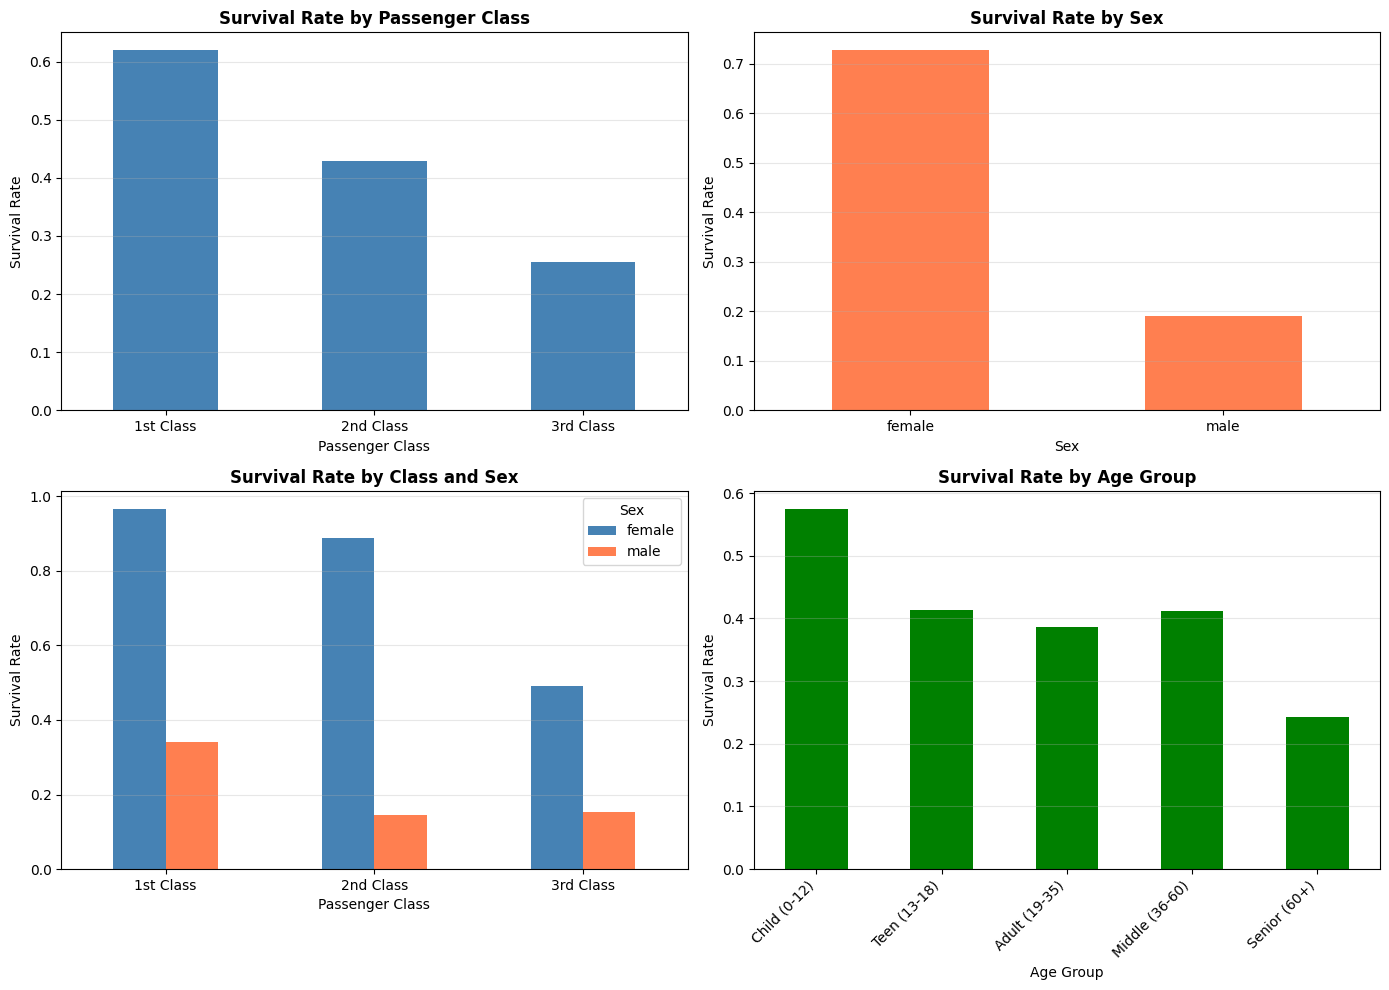

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

class_survival['Survival_Rate'].plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0,0].set_xlabel('Passenger Class')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[0,0].grid(axis='y', alpha=0.3)

sex_survival['Survival_Rate'].plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Survival Rate by Sex', fontweight='bold')
axes[0,1].set_xlabel('Sex')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_xticklabels(sex_survival.index, rotation=0)
axes[0,1].grid(axis='y', alpha=0.3)

class_sex_pivot = titanic_df.pivot_table(values='survived', index='pclass', 
                                          columns='sex', aggfunc='mean')
class_sex_pivot.plot(kind='bar', ax=axes[1,0], color=['steelblue', 'coral'])
axes[1,0].set_title('Survival Rate by Class and Sex', fontweight='bold')
axes[1,0].set_xlabel('Passenger Class')
axes[1,0].set_ylabel('Survival Rate')
axes[1,0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[1,0].legend(title='Sex')
axes[1,0].grid(axis='y', alpha=0.3)

age_survival['Survival_Rate'].plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Survival Rate by Age Group', fontweight='bold')
axes[1,1].set_xlabel('Age Group')
axes[1,1].set_ylabel('Survival Rate')
axes[1,1].set_xticklabels(age_survival.index, rotation=45, ha='right')
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
print(" 2.4: LOGISTIC REGRESSION MODEL")
print("="*70)

titanic_model = titanic_df[['survived', 'pclass', 'sex', 'age']].copy()

print(f"\nMissing values before cleaning:\n{titanic_model.isnull().sum()}")

titanic_model = titanic_model.dropna()

print(f"\nDataset size after removing missing: {len(titanic_model)} rows")

titanic_model['sex_numeric'] = (titanic_model['sex'] == 'male').astype(int)

print(f"\nSex encoding: female=0, male=1")
print(titanic_model[['sex', 'sex_numeric']].drop_duplicates())

X = titanic_model[['pclass', 'sex_numeric', 'age']]
y = titanic_model['survived']

print(f"\nPredictors (X):\n{X.head()}")
print(f"\nTarget (y):\n{y.head()}")

 2.4: LOGISTIC REGRESSION MODEL

Missing values before cleaning:
survived      0
pclass        0
sex           0
age         263
dtype: int64

Dataset size after removing missing: 1046 rows

Sex encoding: female=0, male=1
      sex  sex_numeric
0  female            0
1    male            1

Predictors (X):
   pclass  sex_numeric    age
0       1            0  29.00
1       1            1   0.92
2       1            0   2.00
3       1            1  30.00
4       1            0  25.00

Target (y):
0    1
1    1
2    0
3    0
4    0
Name: survived, dtype: int64


In [47]:
print("BUILDING LOGISTIC REGRESSION MODEL")

X_with_const = sm.add_constant(X)
logit_model = sm.Logit(y, X_with_const).fit()

print("\nLOGISTIC REGRESSION MODEL SUMMARY:")
print(logit_model.summary())


BUILDING LOGISTIC REGRESSION MODEL
Optimization terminated successfully.
         Current function value: 0.469897
         Iterations 6

LOGISTIC REGRESSION MODEL SUMMARY:
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                 1046
Model:                          Logit   Df Residuals:                     1042
Method:                           MLE   Df Model:                            3
Date:                Sat, 10 Jan 2026   Pseudo R-squ.:                  0.3051
Time:                        19:16:40   Log-Likelihood:                -491.51
converged:                       True   LL-Null:                       -707.31
Covariance Type:            nonrobust   LLR p-value:                 3.167e-93
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           4.5893      0.406  

In [48]:
print("PARAMETER ESTIMATES AND STATISTICAL SIGNIFICANCE")

params_df = pd.DataFrame({
    'Coefficient': logit_model.params,
    'Std_Error': logit_model.bse,
    'z_value': logit_model.tvalues,
    'p_value': logit_model.pvalues,
    'Odds_Ratio': np.exp(logit_model.params)
})

print("\nPARAMETER ESTIMATES:")
print("-"*70)
print(params_df)

print("\n\n95% CONFIDENCE INTERVALS:")
print("-"*70)
conf_int = logit_model.conf_int()
conf_int.columns = ['Lower_CI', 'Upper_CI']
conf_int['Odds_Ratio_Lower'] = np.exp(conf_int['Lower_CI'])
conf_int['Odds_Ratio_Upper'] = np.exp(conf_int['Upper_CI'])
print(conf_int)

print("STATISTICAL SIGNIFICANCE (α = 0.05)")
print("="*70)

for var in params_df.index:
    coef = params_df.loc[var, 'Coefficient']
    pval = params_df.loc[var, 'p_value']
    odds = params_df.loc[var, 'Odds_Ratio']
    
    if pval < 0.05:
        significance = "SIGNIFICANT "
    else:
        significance = "NOT SIGNIFICANT "
    
    print(f"\n{var}:")
    print(f"  Coefficient (β): {coef:.4f}")
    print(f"  P-value: {pval:.4f} - {significance}")
    print(f"  Odds Ratio: {odds:.4f}")
    
    if var != 'const' and pval < 0.05:
        if coef > 0:
            print(f"  Interpretation: Increases odds of survival by factor of {odds:.3f}")
        else:
            print(f"  Interpretation: Decreases odds of survival by factor of {odds:.3f}")


PARAMETER ESTIMATES AND STATISTICAL SIGNIFICANCE

PARAMETER ESTIMATES:
----------------------------------------------------------------------
             Coefficient  Std_Error    z_value       p_value  Odds_Ratio
const           4.589269   0.405741  11.310829  1.159888e-29   98.422411
pclass         -1.133244   0.111734 -10.142325  3.584638e-24    0.321987
sex_numeric    -2.497377   0.166127 -15.032967  4.465515e-51    0.082301
age            -0.033885   0.006281  -5.395117  6.847893e-08    0.966683


95% CONFIDENCE INTERVALS:
----------------------------------------------------------------------
             Lower_CI  Upper_CI  Odds_Ratio_Lower  Odds_Ratio_Upper
const        3.794031  5.384507         44.435136        218.002503
pclass      -1.352239 -0.914249          0.258661          0.400817
sex_numeric -2.822979 -2.171774          0.059429          0.113975
age         -0.046195 -0.021575          0.954856          0.978656
STATISTICAL SIGNIFICANCE (α = 0.05)

const:
  Coeffici

In [49]:
print("2.5: MODEL PERFORMANCE - CONFUSION MATRIX")

y_pred_prob = logit_model.predict(X_with_const)
y_pred_binary = (y_pred_prob >= 0.5).astype(int)

print("\nPrediction Examples:")
print("-"*70)
comparison = pd.DataFrame({
    'Actual': y.values[:10],
    'Pred_Probability': y_pred_prob.values[:10],
    'Pred_Binary': y_pred_binary.values[:10]
})
print(comparison)


2.5: MODEL PERFORMANCE - CONFUSION MATRIX

Prediction Examples:
----------------------------------------------------------------------
   Actual  Pred_Probability  Pred_Binary
0       1          0.922253            1
1       1          0.716562            1
2       0          0.967335            1
3       0          0.485529            0
4       0          0.931432            1
5       1          0.338983            0
6       1          0.789393            1
7       0          0.410266            0
8       1          0.840254            1
9       0          0.190435            0


In [50]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm = confusion_matrix(y, y_pred_binary)

print("\n\nCONFUSION MATRIX:")
print("="*70)
print("\nActual vs Predicted:")
print("-"*70)
cm_df = pd.DataFrame(cm, 
                     index=['Actual: Died (0)', 'Actual: Survived (1)'],
                     columns=['Predicted: Died (0)', 'Predicted: Survived (1)'])
print(cm_df)

tn, fp, fn, tp = cm.ravel()

print("\n\nConfusion Matrix Components:")
print(f"True Negatives (TN):  {tn} - Correctly predicted deaths")
print(f"False Positives (FP): {fp} - Predicted survival but actually died")
print(f"False Negatives (FN): {fn} - Predicted death but actually survived")
print(f"True Positives (TP):  {tp} - Correctly predicted survivals")

accuracy = accuracy_score(y, y_pred_binary)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("MODEL PERFORMANCE METRICS")
print("="*70)
print(f"\nClassification Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Formula: (TP + TN) / Total = ({tp} + {tn}) / {len(y)} = {accuracy:.4f}")
print(f"\nPrecision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Formula: TP / (TP + FP) = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"\nRecall (Sensitivity): {recall:.4f} ({recall*100:.2f}%)")
print(f"  Formula: TP / (TP + FN) = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"\nSpecificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Formula: TN / (TN + FP) = {tn} / ({tn} + {fp}) = {specificity:.4f}")
print(f"\nF1-Score: {f1_score:.4f}")

print("\n\nDETAILED CLASSIFICATION REPORT:")
print(classification_report(y, y_pred_binary, target_names=['Died (0)', 'Survived (1)']))




CONFUSION MATRIX:

Actual vs Predicted:
----------------------------------------------------------------------
                      Predicted: Died (0)  Predicted: Survived (1)
Actual: Died (0)                      523                       96
Actual: Survived (1)                  126                      301


Confusion Matrix Components:
True Negatives (TN):  523 - Correctly predicted deaths
False Positives (FP): 96 - Predicted survival but actually died
False Negatives (FN): 126 - Predicted death but actually survived
True Positives (TP):  301 - Correctly predicted survivals
MODEL PERFORMANCE METRICS

Classification Accuracy: 0.7878 (78.78%)
  Formula: (TP + TN) / Total = (301 + 523) / 1046 = 0.7878

Precision: 0.7582 (75.82%)
  Formula: TP / (TP + FP) = 301 / (301 + 96) = 0.7582

Recall (Sensitivity): 0.7049 (70.49%)
  Formula: TP / (TP + FN) = 301 / (301 + 126) = 0.7049

Specificity: 0.8449 (84.49%)
  Formula: TN / (TN + FP) = 523 / (523 + 96) = 0.8449

F1-Score: 0.7306


DETAI

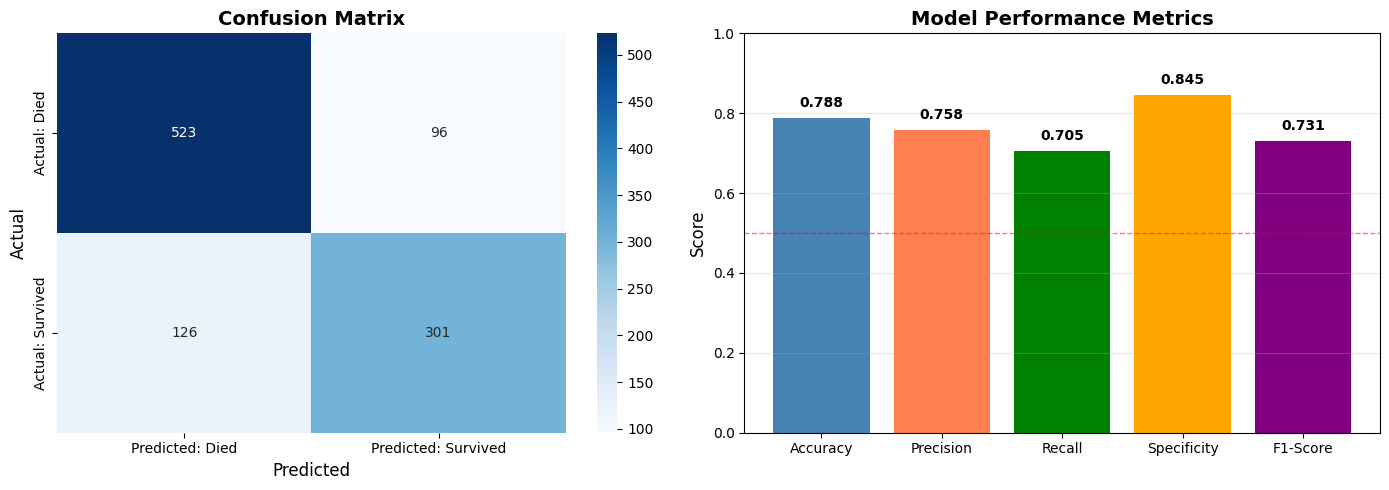

MODEL PERFORMANCE SUMMARY

Classification Accuracy: 0.7878 (78.78%)

Total Correct: 824 out of 1046 (78.8%)
Total Incorrect: 222 out of 1046 (21.2%)


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'])
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

metrics_names = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
metrics_values = [accuracy, precision, recall, specificity, f1_score]

axes[1].bar(metrics_names, metrics_values, color=['steelblue', 'coral', 'green', 'orange', 'purple'])
axes[1].set_title('Model Performance Metrics', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5)

for i, v in enumerate(metrics_values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"\nClassification Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nTotal Correct: {tp + tn} out of {len(y)} ({(tp+tn)/len(y)*100:.1f}%)")
print(f"Total Incorrect: {fp + fn} out of {len(y)} ({(fp+fn)/len(y)*100:.1f}%)")

Daily Returns Shape: (252, 30)

First 5 rows of daily returns:
Ticker          AAPL      AMGN      AMZN       AXP        BA       CAT  \
Date                                                                     
2020-01-03 -0.009722 -0.006789 -0.012139 -0.009932 -0.001680 -0.013884   
2020-01-06  0.007968  0.007674  0.014886 -0.004334  0.002945 -0.000673   
2020-01-07 -0.004703 -0.009405  0.002092 -0.005239  0.010607 -0.013213   
2020-01-08  0.016087  0.000756 -0.007809  0.017260 -0.017523  0.008881   
2020-01-09  0.021241  0.002980  0.004799  0.018082  0.014998 -0.002505   

Ticker           CRM      CSCO       CVX       DIS  ...       MMM       MRK  \
Date                                                ...                       
2020-01-03 -0.004911 -0.016316 -0.003459 -0.011471  ... -0.008611 -0.008583   
2020-01-06  0.043811  0.003569 -0.003388 -0.005802  ...  0.000952  0.004274   
2020-01-07  0.014702 -0.006485 -0.012769  0.000343  ... -0.004031 -0.026626   
2020-01-08  0.007557  0

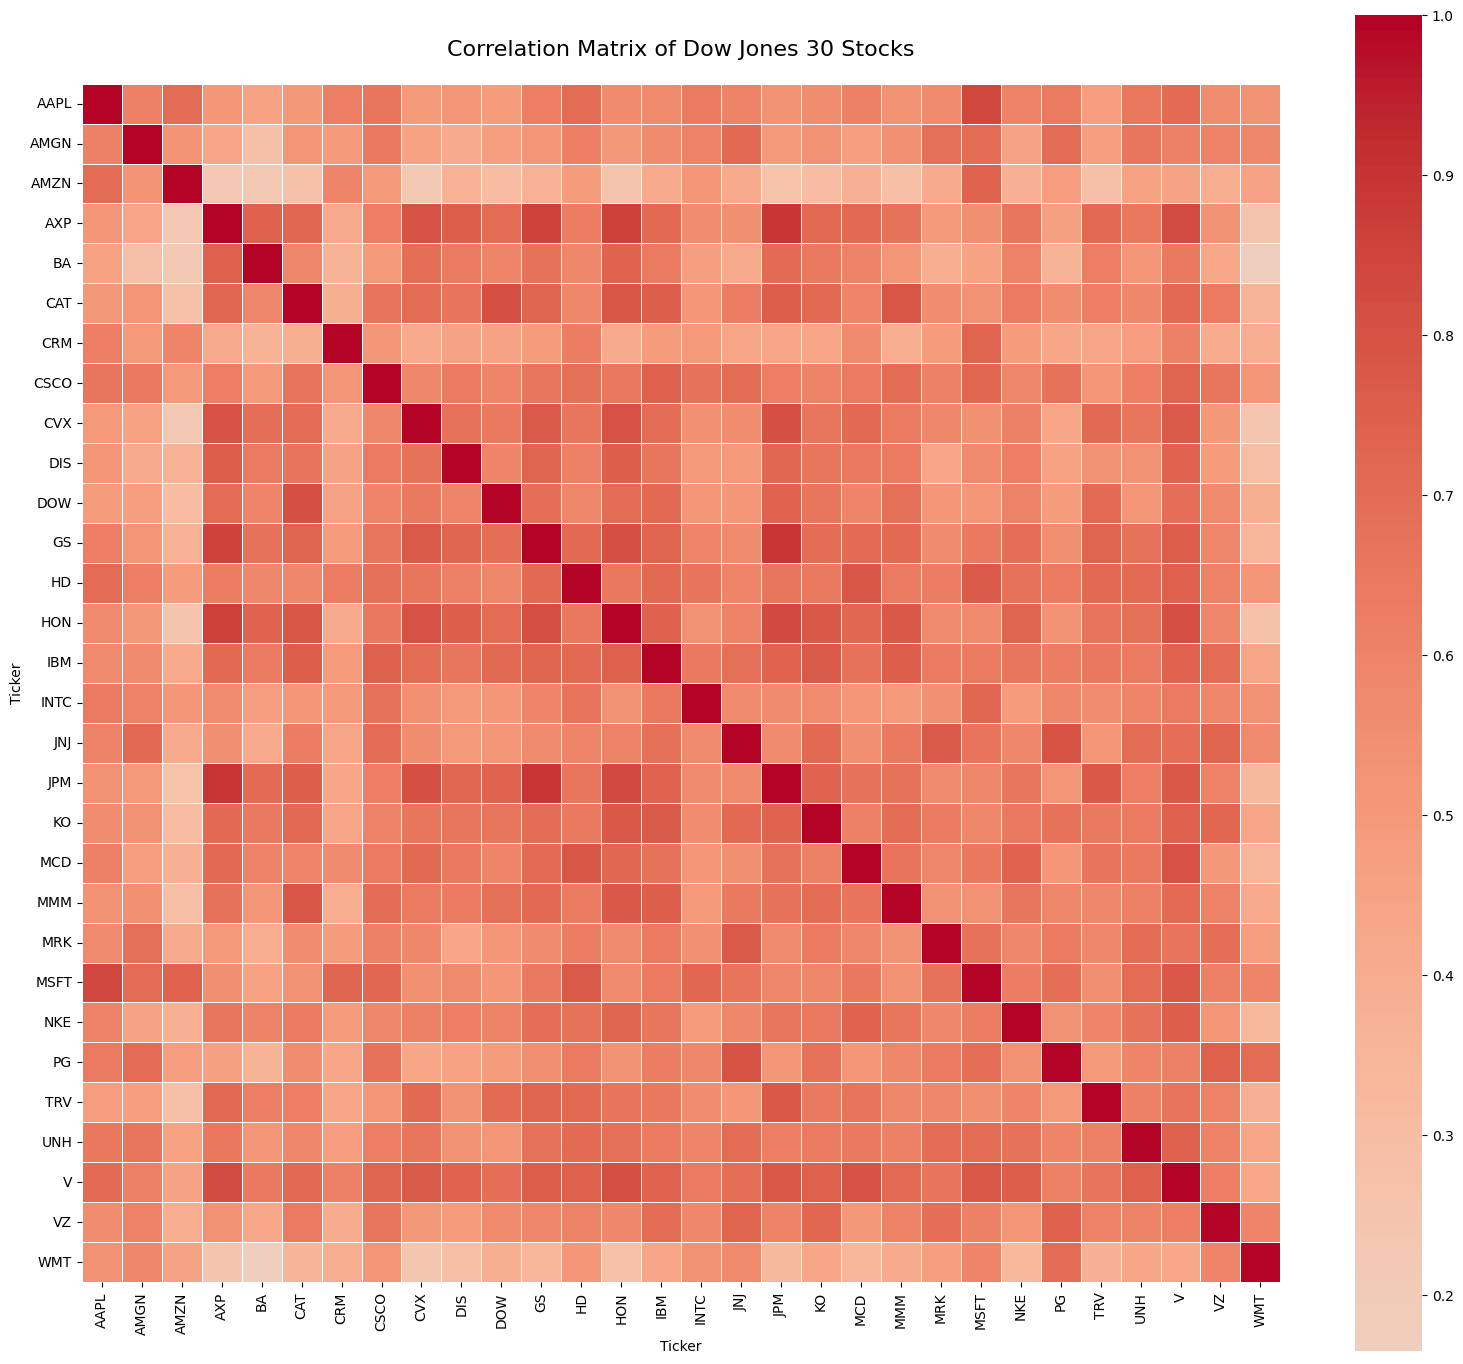

In [52]:
dow_tickers = ['MMM', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CVX', 'CSCO', 
               'KO', 'DIS', 'DOW', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 
               'JPM', 'MCD', 'MRK', 'MSFT', 'NKE', 'PG', 'CRM', 'TRV', 
               'UNH', 'VZ', 'V', 'AMZN', 'WMT']

start_date = '2020-01-01'
end_date = '2021-01-01'

stock_data = yf.download(dow_tickers, start=start_date, end=end_date, progress=False)['Close']

daily_returns = stock_data.pct_change().dropna()

print("Daily Returns Shape:", daily_returns.shape)
print("\nFirst 5 rows of daily returns:")
print(daily_returns.head())

correlation_matrix = daily_returns.corr()

print("\nCorrelation Matrix Shape:", correlation_matrix.shape)
print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Dow Jones 30 Stocks', fontsize=16, pad=20)
plt.tight_layout()
plt.show()


First Principal Component Weights:
   Stock  PC1_Weight
3   AAPL    0.317971
13   HON    0.296637
8     KO    0.285684
4     BA    0.284745
17   JPM    0.284521
11    GS    0.232759
5    CAT    0.227928
9    DIS    0.219404
10   DOW    0.203997
25   UNH    0.194833
20  MSFT    0.185812
18   MCD    0.168563
19   MRK    0.168292
23   CRM    0.160616
27     V    0.154244
14   IBM    0.151456
26    VZ    0.061361
12    HD    0.052388
7   CSCO    0.028518
28  AMZN    0.002248
21   NKE   -0.010729
16   JNJ   -0.018581
15  INTC   -0.031202
0    MMM   -0.086921
6    CVX   -0.091819
24   TRV   -0.094516
22    PG   -0.102090
1    AXP   -0.118734
29   WMT   -0.221383
2   AMGN   -0.249823

Second Principal Component Weights:
   Stock  PC2_Weight
16   JNJ    0.389861
24   TRV    0.367701
28  AMZN    0.329929
1    AXP    0.326323
21   NKE    0.313761
29   WMT    0.267792
7   CSCO    0.225369
26    VZ    0.207189
18   MCD    0.191227
20  MSFT    0.182188
14   IBM    0.165385
22    PG    0.146638
15 

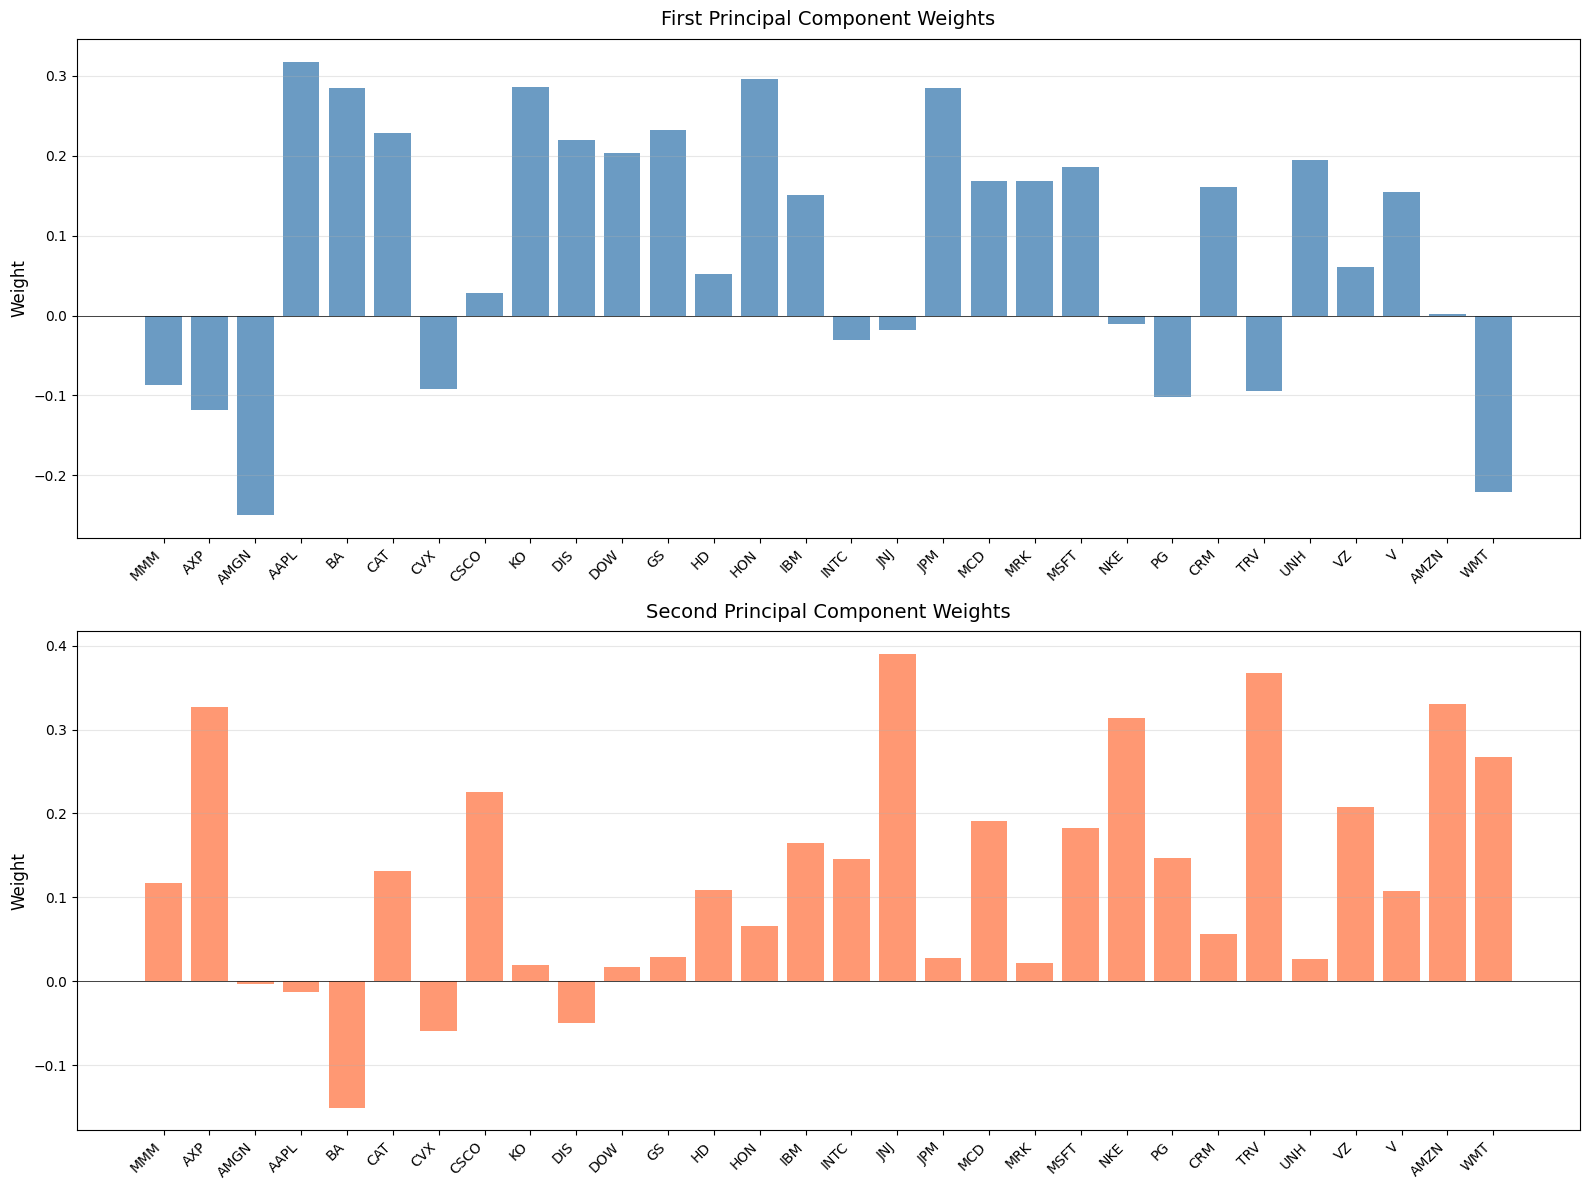

In [53]:

pca_model = PCA()
pca_model.fit(correlation_matrix)

pc1_weights = pca_model.components_[0]
pc2_weights = pca_model.components_[1]

print("\nFirst Principal Component Weights:")
print(pd.DataFrame({'Stock': dow_tickers, 'PC1_Weight': pc1_weights}).sort_values('PC1_Weight', ascending=False))

print("\nSecond Principal Component Weights:")
print(pd.DataFrame({'Stock': dow_tickers, 'PC2_Weight': pc2_weights}).sort_values('PC2_Weight', ascending=False))

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

axes[0].bar(range(len(dow_tickers)), pc1_weights, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(dow_tickers)))
axes[0].set_xticklabels(dow_tickers, rotation=45, ha='right')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_ylabel('Weight', fontsize=12)
axes[0].set_title('First Principal Component Weights', fontsize=14, pad=10)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(dow_tickers)), pc2_weights, color='coral', alpha=0.8)
axes[1].set_xticks(range(len(dow_tickers)))
axes[1].set_xticklabels(dow_tickers, rotation=45, ha='right')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel('Weight', fontsize=12)
axes[1].set_title('Second Principal Component Weights', fontsize=14, pad=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
equal_weight = 1 / len(dow_tickers)

print(f"Equal Weight (Market Portfolio): {equal_weight:.6f} ({equal_weight*100:.4f}%)")
print(f"\nPC1 Statistics:")
print(f"  Mean weight: {np.mean(pc1_weights):.6f}")
print(f"  Mean absolute weight: {np.mean(np.abs(pc1_weights)):.6f}")
print(f"  Standard deviation: {np.std(pc1_weights):.6f}")
print(f"  Min weight: {np.min(pc1_weights):.6f}")
print(f"  Max weight: {np.max(pc1_weights):.6f}")

print(f"\nPC2 Statistics:")
print(f"  Mean weight: {np.mean(pc2_weights):.6f}")
print(f"  Mean absolute weight: {np.mean(np.abs(pc2_weights)):.6f}")
print(f"  Standard deviation: {np.std(pc2_weights):.6f}")
print(f"  Min weight: {np.min(pc2_weights):.6f}")
print(f"  Max weight: {np.max(pc2_weights):.6f}")

print(f"\nPC1 signs: {np.sum(pc1_weights > 0)} positive, {np.sum(pc1_weights < 0)} negative")
print(f"PC2 signs: {np.sum(pc2_weights > 0)} positive, {np.sum(pc2_weights < 0)} negative")


Equal Weight (Market Portfolio): 0.033333 (3.3333%)

PC1 Statistics:
  Mean weight: 0.088539
  Mean absolute weight: 0.156926
  Standard deviation: 0.159669
  Min weight: -0.249823
  Max weight: 0.317971

PC2 Statistics:
  Mean weight: 0.123814
  Mean absolute weight: 0.142049
  Standard deviation: 0.134177
  Min weight: -0.150236
  Max weight: 0.389861

PC1 signs: 20 positive, 10 negative
PC2 signs: 25 positive, 5 negative


In [55]:
explained_variance = pca_model.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Variance_Explained_%': explained_variance * 100,
    'Cumulative_Variance_%': cumulative_variance * 100
})

print("Variance Explained by Each Principal Component:")
print(variance_df.head(15))

Variance Explained by Each Principal Component:
      PC  Variance_Explained_%  Cumulative_Variance_%
0    PC1             55.517565              55.517565
1    PC2             15.186500              70.704065
2    PC3             10.109513              80.813578
3    PC4              3.445635              84.259212
4    PC5              2.798990              87.058202
5    PC6              2.212026              89.270228
6    PC7              1.866542              91.136770
7    PC8              1.511850              92.648619
8    PC9              1.161330              93.809950
9   PC10              1.141693              94.951643
10  PC11              0.755654              95.707298
11  PC12              0.628809              96.336106
12  PC13              0.523781              96.859888
13  PC14              0.453363              97.313250
14  PC15              0.432845              97.746095



Number of principal components required to explain 95% of variance: 11
Cumulative variance with 11 components: 95.71%


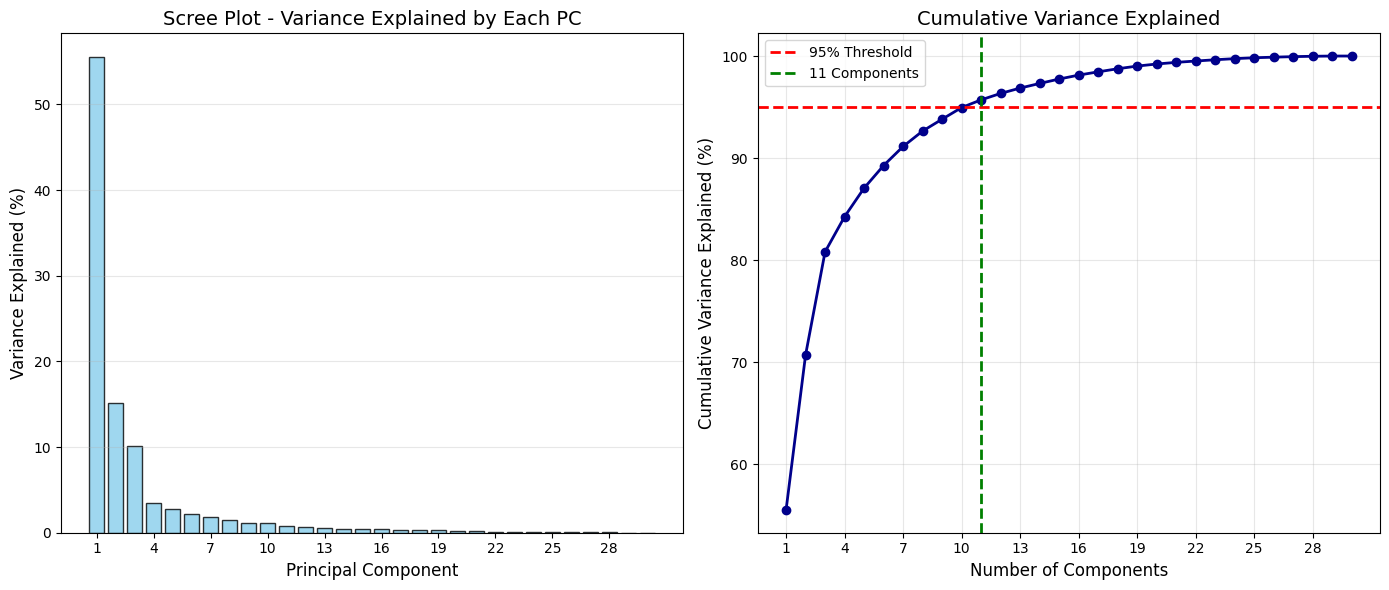

In [56]:
threshold_95 = 0.95
n_components_95 = np.argmax(cumulative_variance >= threshold_95) + 1

print(f"\nNumber of principal components required to explain 95% of variance: {n_components_95}")
print(f"Cumulative variance with {n_components_95} components: {cumulative_variance[n_components_95-1]*100:.2f}%")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance * 100, 
        alpha=0.8, color='skyblue', edgecolor='black')
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Variance Explained (%)', fontsize=12)
plt.title('Scree Plot - Variance Explained by Each PC', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(1, len(explained_variance) + 1, 3))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, 
         marker='o', linewidth=2, markersize=6, color='darkblue')
plt.axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% Threshold')
plt.axvline(x=n_components_95, color='green', linestyle='--', linewidth=2, 
            label=f'{n_components_95} Components')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained (%)', fontsize=12)
plt.title('Cumulative Variance Explained', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.xticks(range(1, len(cumulative_variance) + 1, 3))

plt.tight_layout()
plt.show()


Principal Components from Daily Returns:
Shape: (252, 2)

First 5 rows:
                 PC1       PC2
Date                          
2020-01-03 -2.006548 -0.504759
2020-01-06  0.293353  0.618713
2020-01-07 -1.271175 -0.462910
2020-01-08  0.959511 -0.163905
2020-01-09  1.137455  0.316182


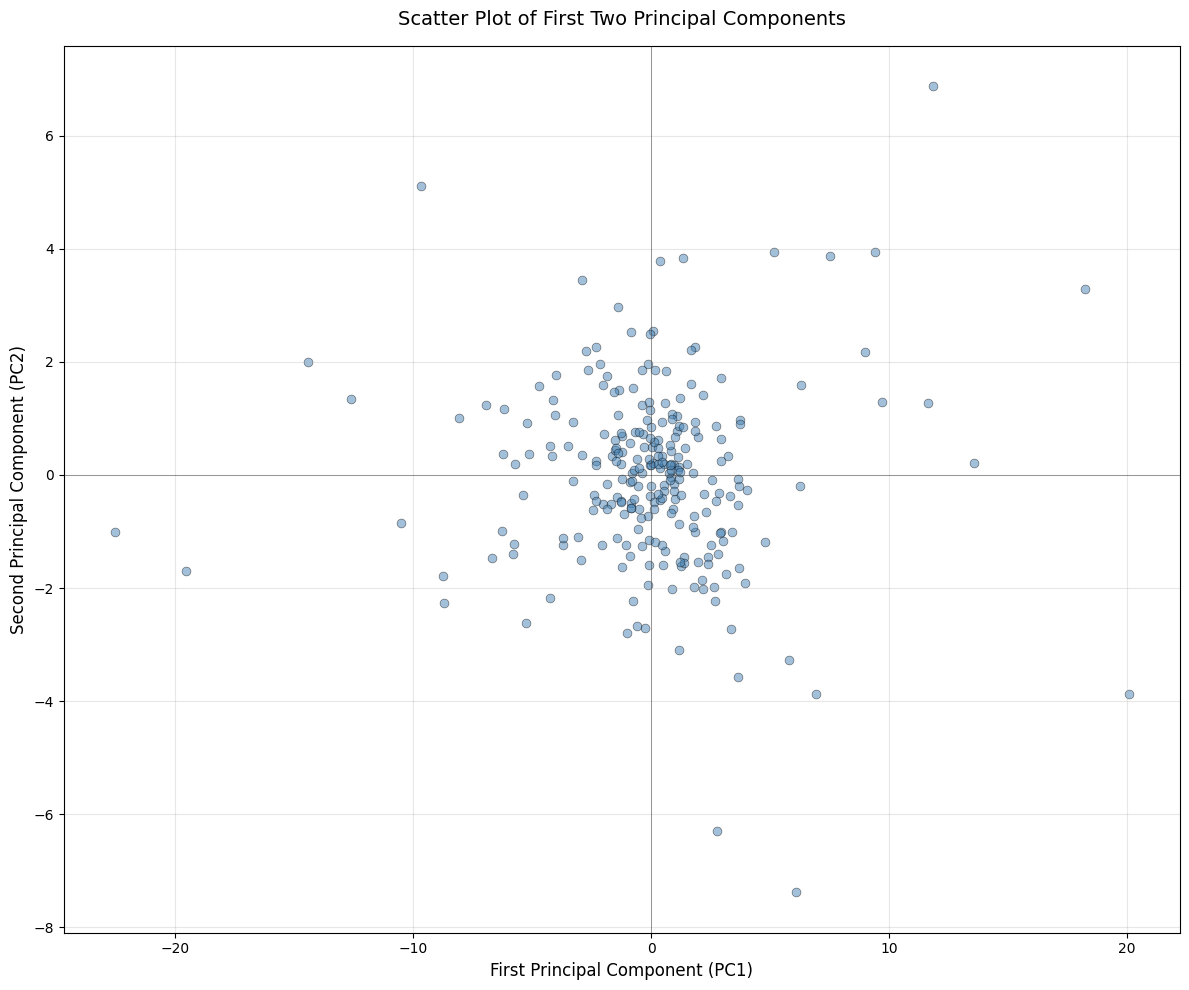

In [57]:
returns_standardized = StandardScaler().fit_transform(daily_returns)
pca_transform = PCA(n_components=2)
principal_components_returns = pca_transform.fit_transform(returns_standardized)

pc_returns_df = pd.DataFrame(
    data=principal_components_returns, 
    columns=['PC1', 'PC2'],
    index=daily_returns.index
)

print("Principal Components from Daily Returns:")
print(f"Shape: {principal_components_returns.shape}")
print("\nFirst 5 rows:")
print(pc_returns_df.head())

plt.figure(figsize=(12, 10))
plt.scatter(pc_returns_df['PC1'], pc_returns_df['PC2'], 
            alpha=0.5, s=40, c='steelblue', edgecolors='black', linewidth=0.5)
plt.xlabel('First Principal Component (PC1)', fontsize=12)
plt.ylabel('Second Principal Component (PC2)', fontsize=12)
plt.title('Scatter Plot of First Two Principal Components', fontsize=14, pad=15)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
stock_pc_scores = pca_model.transform(correlation_matrix)

stock_pc_df = pd.DataFrame(
    data=stock_pc_scores[:, :2],
    columns=['PC1_Score', 'PC2_Score'],
    index=dow_tickers
)

print("PC Scores for Each Stock (from correlation matrix):")
print(stock_pc_df)

mean_pc1 = stock_pc_df['PC1_Score'].mean()
mean_pc2 = stock_pc_df['PC2_Score'].mean()

print(f"\nMean of all 30 stocks for PC1: {mean_pc1:.6f}")
print(f"Mean of all 30 stocks for PC2: {mean_pc2:.6f}")


PC Scores for Each Stock (from correlation matrix):
      PC1_Score  PC2_Score
MMM   -0.479912   0.051576
AXP   -0.676247   0.234625
AMGN  -1.343729  -0.601837
AAPL   0.701848  -0.197212
BA     0.388271  -0.668261
CAT    0.429911   0.024596
CVX   -0.733524  -0.516468
CSCO  -0.087139   0.268859
KO     0.554894  -0.215014
DIS    0.330339  -0.340524
DOW    0.315098  -0.189831
GS     0.544878   0.001885
HD     0.034265   0.161909
HON    0.691690  -0.007872
IBM    0.327247   0.243846
INTC  -0.388051  -0.004345
JNJ   -0.276904   0.455014
JPM    0.655129  -0.060090
MCD    0.311678   0.194514
MRK    0.267547  -0.124987
MSFT   0.294208   0.084097
NKE   -0.318195   0.253590
PG    -0.402764   0.262001
CRM    0.204181  -0.123043
TRV   -0.541126   0.379952
UNH    0.286261  -0.184190
VZ    -0.028229   0.188062
V      0.415834   0.256865
AMZN  -0.254814   0.318071
WMT   -1.222646  -0.145789

Mean of all 30 stocks for PC1: 0.000000
Mean of all 30 stocks for PC2: 0.000000


In [59]:
stock_pc_df['Distance_from_Mean'] = stock_pc_df.apply(
    lambda row: euclidean([row['PC1_Score'], row['PC2_Score']], [mean_pc1, mean_pc2]), 
    axis=1
)

stock_distances_sorted = stock_pc_df.sort_values('Distance_from_Mean', ascending=False)

print("Euclidean Distances from Mean (sorted):")
print(stock_distances_sorted)

Euclidean Distances from Mean (sorted):
      PC1_Score  PC2_Score  Distance_from_Mean
AMGN  -1.343729  -0.601837            1.472350
WMT   -1.222646  -0.145789            1.231307
CVX   -0.733524  -0.516468            0.897105
BA     0.388271  -0.668261            0.772870
AAPL   0.701848  -0.197212            0.729029
AXP   -0.676247   0.234625            0.715792
HON    0.691690  -0.007872            0.691735
TRV   -0.541126   0.379952            0.661196
JPM    0.655129  -0.060090            0.657879
KO     0.554894  -0.215014            0.595095
GS     0.544878   0.001885            0.544881
JNJ   -0.276904   0.455014            0.532648
V      0.415834   0.256865            0.488771
MMM   -0.479912   0.051576            0.482675
PG    -0.402764   0.262001            0.480483
DIS    0.330339  -0.340524            0.474426
CAT    0.429911   0.024596            0.430614
IBM    0.327247   0.243846            0.408107
AMZN  -0.254814   0.318071            0.407553
NKE   -0.318195   0.

In [60]:
top_3_distant = stock_distances_sorted.head(3)

print("\n" + "="*70)
print("THREE MOST DISTANT STOCKS FROM THE MEAN")
print("="*70)
print(top_3_distant)

for stock in top_3_distant.index:
    print(f"\n{stock}:")
    print(f"  PC1 Score: {stock_pc_df.loc[stock, 'PC1_Score']:.6f}")
    print(f"  PC2 Score: {stock_pc_df.loc[stock, 'PC2_Score']:.6f}")
    print(f"  Distance from Mean: {stock_pc_df.loc[stock, 'Distance_from_Mean']:.6f}")



THREE MOST DISTANT STOCKS FROM THE MEAN
      PC1_Score  PC2_Score  Distance_from_Mean
AMGN  -1.343729  -0.601837            1.472350
WMT   -1.222646  -0.145789            1.231307
CVX   -0.733524  -0.516468            0.897105

AMGN:
  PC1 Score: -1.343729
  PC2 Score: -0.601837
  Distance from Mean: 1.472350

WMT:
  PC1 Score: -1.222646
  PC2 Score: -0.145789
  Distance from Mean: 1.231307

CVX:
  PC1 Score: -0.733524
  PC2 Score: -0.516468
  Distance from Mean: 0.897105


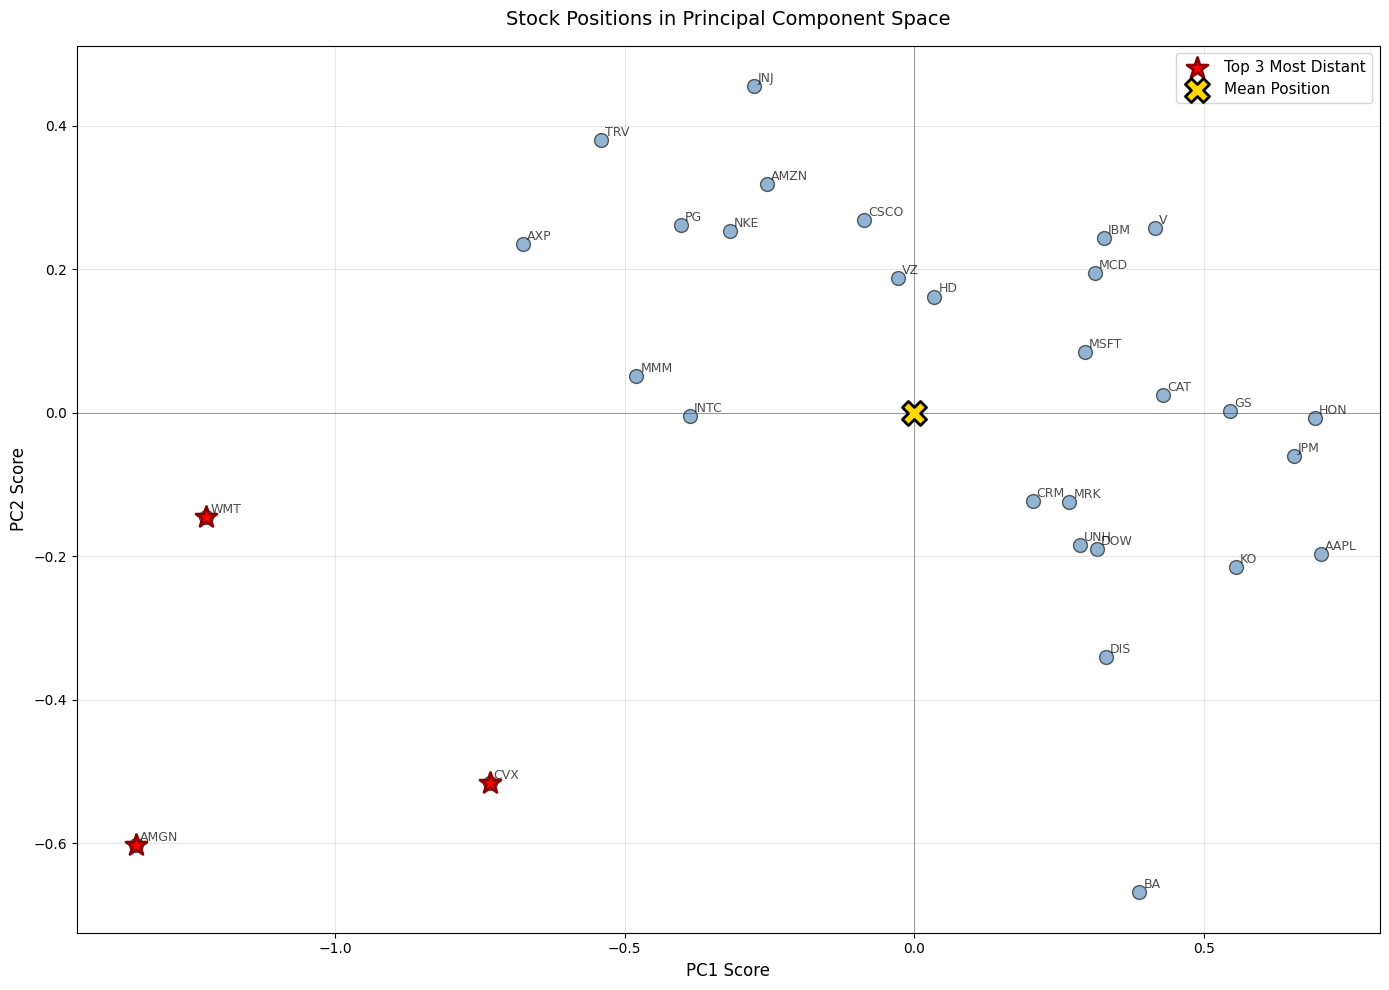

In [61]:
plt.figure(figsize=(14, 10))

plt.scatter(stock_pc_df['PC1_Score'], stock_pc_df['PC2_Score'], 
            alpha=0.6, s=100, c='steelblue', edgecolors='black', linewidth=1)

for stock in stock_pc_df.index:
    plt.annotate(stock, 
                (stock_pc_df.loc[stock, 'PC1_Score'], stock_pc_df.loc[stock, 'PC2_Score']), 
                fontsize=9, alpha=0.7, xytext=(3, 3), textcoords='offset points')

plt.scatter(top_3_distant['PC1_Score'], top_3_distant['PC2_Score'], 
            s=250, c='red', edgecolors='darkred', linewidth=2, 
            marker='*', label='Top 3 Most Distant', zorder=5)

plt.scatter(mean_pc1, mean_pc2, s=300, c='gold', marker='X', 
            edgecolors='black', linewidth=2, label='Mean Position', zorder=5)

plt.xlabel('PC1 Score', fontsize=12)
plt.ylabel('PC2 Score', fontsize=12)
plt.title('Stock Positions in Principal Component Space', fontsize=14, pad=15)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
print("\n" + "="*70)
print("ANALYSIS: WHY THESE STOCKS ARE UNUSUAL")
print("="*70)

for stock in top_3_distant.index:
    stock_returns = daily_returns[stock]
    total_return = (1 + stock_returns).prod() - 1
    
    print(f"\n{stock}:")
    print(f"  Mean Daily Return: {stock_returns.mean()*100:.4f}%")
    print(f"  Std Daily Return: {stock_returns.std()*100:.4f}%")
    print(f"  Total Return (2020): {total_return*100:.2f}%")
    print(f"  Sharpe Ratio (approx): {stock_returns.mean()/stock_returns.std():.4f}")
    print(f"  Min Daily Return: {stock_returns.min()*100:.2f}%")
    print(f"  Max Daily Return: {stock_returns.max()*100:.2f}%")
    
    correlation_with_market = daily_returns.corrwith(daily_returns.mean(axis=1))[stock]
    print(f"  Correlation with Market Average: {correlation_with_market:.4f}")



ANALYSIS: WHY THESE STOCKS ARE UNUSUAL

AMGN:
  Mean Daily Return: 0.0224%
  Std Daily Return: 2.4180%
  Total Return (2020): -1.59%
  Sharpe Ratio (approx): 0.0093
  Min Daily Return: -8.26%
  Max Daily Return: 10.90%
  Correlation with Market Average: 0.6944

WMT:
  Mean Daily Return: 0.1023%
  Std Daily Return: 1.9881%
  Total Return (2020): 23.22%
  Sharpe Ratio (approx): 0.0514
  Min Daily Return: -9.07%
  Max Daily Return: 11.71%
  Correlation with Market Average: 0.5330

CVX:
  Mean Daily Return: -0.0473%
  Std Daily Return: 3.8516%
  Total Return (2020): -26.51%
  Sharpe Ratio (approx): -0.0123
  Min Daily Return: -22.12%
  Max Daily Return: 22.74%
  Correlation with Market Average: 0.8171


In [63]:
stock_pc_df['Distance_PC1'] = np.abs(stock_pc_df['PC1_Score'] - mean_pc1)
stock_pc_df['Distance_PC2'] = np.abs(stock_pc_df['PC2_Score'] - mean_pc2)

top_3_pc1 = stock_pc_df.nlargest(3, 'Distance_PC1')
top_3_pc2 = stock_pc_df.nlargest(3, 'Distance_PC2')

print("\n" + "="*70)
print("THREE MOST DISTANT STOCKS FOR EACH PRINCIPAL COMPONENT")
print("="*70)

print("\nMost Distant for PC1:")
print(top_3_pc1[['PC1_Score', 'Distance_PC1']])

print("\nMost Distant for PC2:")
print(top_3_pc2[['PC2_Score', 'Distance_PC2']])



THREE MOST DISTANT STOCKS FOR EACH PRINCIPAL COMPONENT

Most Distant for PC1:
      PC1_Score  Distance_PC1
AMGN  -1.343729      1.343729
WMT   -1.222646      1.222646
CVX   -0.733524      0.733524

Most Distant for PC2:
      PC2_Score  Distance_PC2
BA    -0.668261      0.668261
AMGN  -0.601837      0.601837
CVX   -0.516468      0.516468


In [64]:
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

print(f"\nTotal Stocks Analyzed: {len(dow_tickers)}")
print(f"Time Period: {start_date} to {end_date}")
print(f"Number of Trading Days: {len(daily_returns)}")

print(f"\nPCA Results:")
print(f"  Variance explained by PC1: {pca_model.explained_variance_ratio_[0]*100:.2f}%")
print(f"  Variance explained by PC2: {pca_model.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Total variance (PC1+PC2): {(pca_model.explained_variance_ratio_[0] + pca_model.explained_variance_ratio_[1])*100:.2f}%")
print(f"  Components for 95% variance: {n_components_95}")

print(f"\nMost Distant Stocks Overall: {', '.join(top_3_distant.index.tolist())}")


SUMMARY STATISTICS

Total Stocks Analyzed: 30
Time Period: 2020-01-01 to 2021-01-01
Number of Trading Days: 252

PCA Results:
  Variance explained by PC1: 55.52%
  Variance explained by PC2: 15.19%
  Total variance (PC1+PC2): 70.70%
  Components for 95% variance: 11

Most Distant Stocks Overall: AMGN, WMT, CVX
